# Generación, limpieza y transformación de un DataSet el principio GIGO

Fecha: 28 de mayo del 2026

Autor: Emmanuel Peña Ruiz


# Objetivo general
identificar problemas de calidad de datos,aplicar técnicas de limpieza y transformación,
y analizar cómo los datos incorrectos afectan el análisis y los modelos de Machine Learning mediante el principio GIGO.

# Actividad

Identifique y documente:

- Valores nulos
- Outliers (Negativos o fuera de rango)
- Datos inválidos
- Facturas canceladas ( identificadas con la letra c)
- Duplicados
- Problemas de formato o tipo de datos (Fechas o Monto)

Posteriormente:

- Limpie el dataset
- Transforme los datos
- Justifique las decisiones tomadas
- Explique cómo afecta el principio GIGO al análisis de datos y Machine Learning

# Graficas solicitadas para la identificación de anomalias
1. Ventas por pais
2. Heatmap de valores nulos
3. Distribución del monto

# Nota: 
Al terminar exportar el dataset limpio a formato csv y subir junto con el Laboratorio a GitHub, cumpliendo  con la siguiente estructura.

    - Notebooks (Folder)
        - Lab07.ipynb
    - DataSet (Folder)
        - Data_Limpio_Factura.csv

In [1]:
#importar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Cargamos dataset sucio 
dfSucio = pd.read_csv("ventas-por-factura.csv")

In [3]:
dfSucio.shape

In [4]:
dfSucio.head()

In [5]:
dfSucio.tail()

In [6]:
print(dfSucio.shape)


(25953, 6)


In [7]:
dfSucio.info()


<class 'pandas.DataFrame'>
RangeIndex: 25953 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   N° de factura     25953 non-null  str    
 1   Fecha de factura  25953 non-null  str    
 2   ID Cliente        22229 non-null  float64
 3   País              25953 non-null  str    
 4   Cantidad          25953 non-null  int64  
 5   Monto             25953 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 1.2 MB


In [8]:
dfSucio.describe(include='all')

In [9]:
dfSucio.isnull().sum()

In [10]:
dfSucio.duplicated().sum()

In [11]:
dfSucio.describe()

In [12]:
# Renombramos las columnas para evitar problemas con caracteres especiales y espacios
dfSucio.columns = ['No_Factura', 'Fecha_Factura', 'ID_Cliente', 'Pais', 'Cantidad', 'Monto']
print("Nuevos nombres de columnas:")
print(dfSucio.columns.tolist())


Nuevos nombres de columnas:
['No_Factura', 'Fecha_Factura', 'ID_Cliente', 'Pais', 'Cantidad', 'Monto']


In [13]:
# Convertimos el Monto a float (reemplazando comas por puntos)
dfSucio['Monto'] = dfSucio['Monto'].str.replace(',', '.').astype(float)

# Convertimos la fecha a datetime
dfSucio['Fecha_Factura'] = pd.to_datetime(dfSucio['Fecha_Factura'])

# Mostramos los tipos de datos actualizados
print(dfSucio.dtypes)


No_Factura                  str
Fecha_Factura    datetime64[us]
ID_Cliente              float64
Pais                        str
Cantidad                  int64
Monto                   float64
dtype: object


In [14]:
# Identificamos duplicados
duplicates_cnt = dfSucio.duplicated().sum()
print(f"Número de filas duplicadas: {duplicates_cnt}")

# Identificamos valores nulos en ID_Cliente
null_customers = dfSucio['ID_Cliente'].isnull().sum()
print(f"Valores nulos en ID_Cliente: {null_customers}")

# Identificamos facturas canceladas (comienzan con C)
canceled_cnt = dfSucio['No_Factura'].astype(str).str.upper().str.startswith('C').sum()
print(f"Facturas canceladas (Invoice starts with C): {canceled_cnt}")

# Identificamos facturas de ajuste (comienzan con A)
adjusted_cnt = dfSucio['No_Factura'].astype(str).str.upper().str.startswith('A').sum()
print(f"Facturas de ajuste (Invoice starts with A): {adjusted_cnt}")

# Identificamos cantidades no positivas
negative_qty = (dfSucio['Cantidad'] <= 0).sum()
print(f"Cantidad <= 0: {negative_qty}")

# Identificamos montos no positivos
negative_amount = (dfSucio['Monto'] <= 0).sum()
print(f"Monto <= 0: {negative_amount}")


Número de filas duplicadas: 10
Valores nulos en ID_Cliente: 3724
Facturas canceladas (Invoice starts with C): 3841
Facturas de ajuste (Invoice starts with A): 3
Cantidad <= 0: 5179
Monto <= 0: 5948


# Justificación de las Decisiones de Limpieza

Para garantizar la calidad del dataset y que el análisis subsiguiente no esté sesgado (evitando el principio GIGO), tomamos las siguientes decisiones:
1. **Eliminar Duplicados**: Las filas duplicadas (10 filas) representan redundancia en los datos y se eliminan para no inflar artificialmente las ventas.
2. **Eliminar Inactivas / Cancelaciones y Ajustes**: Las facturas que comienzan con 'C' o 'A' corresponden a devoluciones, cancelaciones o ajustes. Como queremos analizar las ventas efectivas, estas se descartan.
3. **Valores Negativos o Cero**: Las transacciones con `Cantidad <= 0` o `Monto <= 0` son anomalías operativas (errores de sistema, correcciones de inventario, etc.) y se eliminan del análisis de ingresos.
4. **Valores Nulos en ID Cliente**: Encontramos 3,724 valores nulos. Para no perder la contribución de estas ventas al volumen de ingresos totales, decidimos **completar** el `ID_Cliente` nulo con `-1` (etiqueta: "Cliente Anónimo"), convirtiendo la columna a tipo entero. Esto conserva la representatividad financiera del dataset mientras aísla a los clientes desconocidos para análisis de comportamiento específicos.


In [15]:
# Copia para limpieza
dfClean = dfSucio.copy()

# 1. Eliminar duplicados
dfClean = dfClean.drop_duplicates()

# 2. Remover cancelaciones ('C') y ajustes ('A')
dfClean = dfClean[~dfClean['No_Factura'].astype(str).str.upper().str.startswith('C')]
dfClean = dfClean[~dfClean['No_Factura'].astype(str).str.upper().str.startswith('A')]

# 3. Filtrar por cantidades y montos positivos
dfClean = dfClean[(dfClean['Cantidad'] > 0) & (dfClean['Monto'] > 0)]

# 4. Imputar valores nulos en ID_Cliente con -1
dfClean['ID_Cliente'] = dfClean['ID_Cliente'].fillna(-1).astype(int)

# Mostramos dimensiones finales del dataset limpio
print("Dimensiones del dataset original:", dfSucio.shape)
print("Dimensiones del dataset limpio:", dfClean.shape)


Dimensiones del dataset original: (25953, 6)
Dimensiones del dataset limpio: (20001, 6)


In [16]:
import os
# Creamos la carpeta DataSet si no existe (relativa a donde estará el notebook, es decir, un nivel arriba)
os.makedirs("../DataSet", exist_ok=True)
os.makedirs("DataSet", exist_ok=True) # por si acaso

# Exportamos a csv
dfClean.to_csv("../DataSet/Data_Limpio_Factura.csv", index=False, encoding="utf-8")
dfClean.to_csv("DataSet/Data_Limpio_Factura.csv", index=False, encoding="utf-8")
print("Dataset limpio exportado exitosamente a '../DataSet/Data_Limpio_Factura.csv'")


Dataset limpio exportado exitosamente a '../DataSet/Data_Limpio_Factura.csv'


# Visualizaciones Requeridas

A continuación, se generan los gráficos con los datos limpios para asegurar su correcta interpretación:
1. Heatmap de valores nulos (verificando que ya no existan).
2. Ventas por país (monto total acumulado).
3. Distribución del monto de factura.


<string>:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


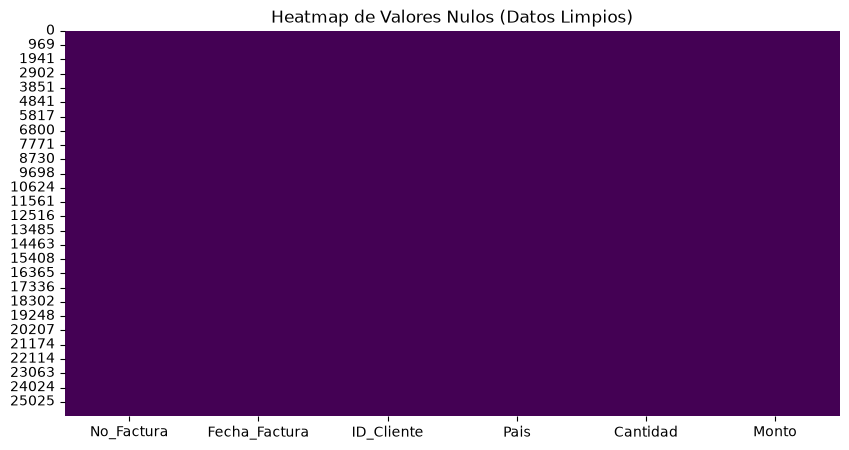

In [17]:
# Graficamos el Heatmap de valores nulos con datos limpios
plt.figure(figsize=(10, 5))
sns.heatmap(dfClean.isnull(), cbar=False, cmap='viridis')
plt.title("Heatmap de Valores Nulos (Datos Limpios)")
plt.show()


<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


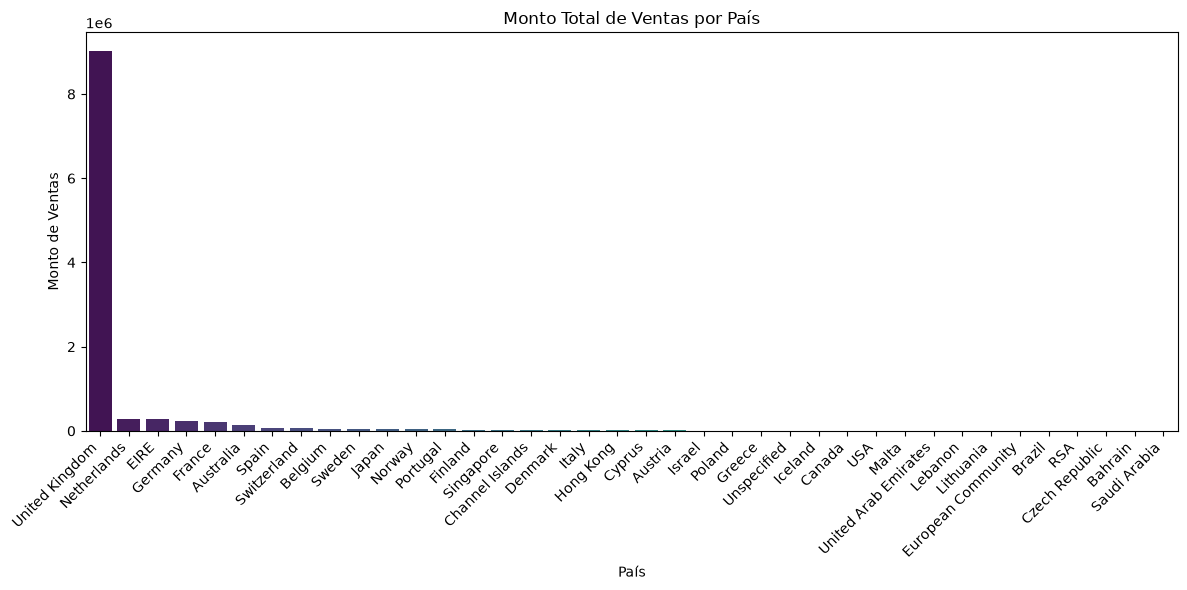

In [18]:
# Agrupamos ventas por país con datos limpios
ventas_por_pais = dfClean.groupby('Pais')['Monto'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=ventas_por_pais, x='Pais', y='Monto', palette='viridis')
plt.title("Monto Total de Ventas por País")
plt.xlabel("País")
plt.ylabel("Monto de Ventas")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


<string>:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


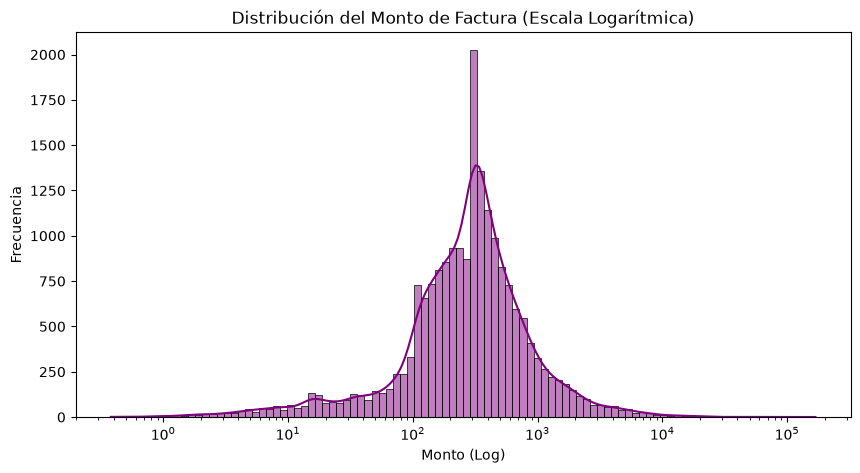

In [19]:
# Distribución del Monto (con escala logarítmica debido a la amplia diferencia de escala)
plt.figure(figsize=(10, 5))
sns.histplot(dfClean['Monto'], bins=100, kde=True, color='purple', log_scale=True)
plt.title("Distribución del Monto de Factura (Escala Logarítmica)")
plt.xlabel("Monto (Log)")
plt.ylabel("Frecuencia")
plt.show()


# Explicación del Principio GIGO (Garbage In, Garbage Out)

El principio **GIGO** (Basura entra, Basura sale) establece que si los datos de entrada en un sistema informático o modelo matemático son incorrectos, inconsistentes, ruidosos o están incompletos (basura), el resultado que genere dicho sistema o modelo será igualmente deficiente o erróneo (basura).

### Impacto en Análisis de Datos
Si no se realiza la limpieza:
1. **Métricas Infladas o Sesgadas**: La suma de ventas habría incluido facturas canceladas o montos negativos de ajustes, lo cual distorsionaría las ventas netas reales.
2. **Tipos de Datos Incorrectos**: Tratar el `Monto` como texto (con formato de coma europea) impide realizar operaciones aritméticas básicas de manera correcta (como sumas o promedios) y causa fallos de visualización.
3. **Análisis de Clientes Erróneo**: Dejar los `ID_Cliente` como nulos en análisis grupales o de retención sesgaría las estadísticas y complicaría el filtrado de transacciones.

### Impacto en Modelos de Machine Learning
1. **Patrones Falsos**: Un algoritmo de aprendizaje supervisado o no supervisado (como K-Means para segmentación de clientes) encontraría agrupaciones basadas en registros erróneos (como clientes con compras masivas negativas).
2. **Sobreajuste o Error en la Generalización**: El modelo intentará ajustar su aprendizaje al ruido (las facturas duplicadas o nulos), lo que resultará en predicciones inexactas en entornos de producción.
